En esta tarea semanal se buscó observar la relacion entre el ruido por cuantizacion y el paso de cuantizacion de un ADC. Para esto se utilizó una señal sinusoidal con ruido analogico y un ADC al cual se le va a ir cambiando su paso de cuantizacion. El ruido analogico fue simulado con ditrubucion 
normal y con su potencia definida a escala de la potencia de ruido generada por cuantizar la señal en el ADC. 

Pn = kn * Pq

Esta relacion se utilizó para oberservar el comportamiento de este ruido con el del ruido propio de la señal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## parameros universales
fs = 1000                     # frecuencia de muestreo
N = 1000                      # muestras
nn = np.arange(0,N)           # vector de muestras
df = fs/N                     # Delta f
frec= np.arange(N//2) * fs/N  # vector de frecuencia
tt=nn/fs

def func_seno(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return (tt,xx)

def mdbn (señal): #devuelve el modulo de la señal normalizado en 0dB
    
    señal_tr = (1/N) * np.fft.fft(señal)             # fft normalizada de la señal 
    modulo_señal = np.abs(señal_tr)                # 
    modulo_señal_db = 10 * np.log10(2*(np.abs(modulo_señal[:N//2]))**2)   # pone 0dB como referencia de 1W de potencia
    return (modulo_señal_db)

def ADC (señal, qq):
    señal_cuant = np.round(señal/qq)*qq       # señal cuantizada
    ruido_por_cuant = señal_cuant - señal     # ruido consecuencia por cuantizacion (señal original - señal cuantizada)
    return(señal_cuant, ruido_por_cuant)

def turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq):
    mra = np.mean(modulo_xxrtr_db)
    mnq = np.mean(modulo_xxqtr_db)
    
    fig, (ax1) = plt.subplots(figsize=(16,9))
    ax1.plot(frec, modulo_xxrtr_db, color='blue')                            # señal original (con ruido)
    ax1.plot(frec, modulo_xxtr_db, color='orange'      , linestyle = ':' )   # señal sin ruido
    ax1.plot(frec, modulo_xxqtr_db, color='hotpink'    , linestyle = '--' )  # señal cuantizada
    ax1.plot(frec, [mra]*len(frec), linestyle = '--')   # piso de ruido señal analogica
    ax1.plot(frec, [mnq]*len(frec) , linestyle = '--')   # piso de ruido señal cuantizada
    ax1.set_title(f"Señal muestreada por un ADC de {B} bits, Vref = ±{Vfs}V, q = {qq:.2}")
    ax1.set_xlabel("Frecuencia")
    ax1.set_ylabel("Amplitud [dB]")
    ax1.set_ylim(mra-30,10)
    ax1.legend(['señal + ruido (entrada ADC)',
                'señal sin ruido',
                'señal cuantizada (salida ADC)',
               f'valor medio del ruido de la señal = {mra:.2f}',
               f'valor medio del ruido de señal cuant = {mnq:.2f}'])
    
    ax1.grid(True)
        
    plt.tight_layout()
    plt.show()
    
def graficar_par(x1, y1, xx, xxq, x2, y2, y3, y4, color1):

    mra = np.mean(y2)
    mnq = np.mean(y4)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 8))
    
    ax1.plot(x1, y1, color='blue')                          #s+r
    ax1.plot(x1, xxq, color='hotpink', linestyle = '--' )    #sq
    ax1.plot(x1, xx, linestyle = '--', color='lightgreen')  #s
    ax1.set_title("Señal")
    ax1.grid(True)
    ax1.set_xlabel("Tiempo [ms]")
    ax1.set_ylabel("Amplitud [V]")
    ax1.legend(['señal + ruido (entrada ADC)',
                'señal cuantizada',
                'señal sin ruido'])
    
    ax2.plot(x2, y2, color='blue')                          #s+r
    ax2.plot(x2, y4, color='hotpink' , linestyle = '--' )    #sq
    ax2.plot(x2, y3, color='orange', linestyle = ':' )      #S
    ax2.plot(frec, [mra]*len(frec), linestyle = '--')   # piso de ruido señal analogica
    ax2.plot(frec, [mnq]*len(frec) , linestyle = '--')   # piso de ruido señal cuantizada
    ax2.set_title("Espectro")
    ax2.grid(True)
    ax2.set_xlabel("Frecuencia")
    ax2.set_ylabel("Amplitud [dB]")
    ax2.set_ylim(-90,10)
    ax2.legend(['señal + ruido (entrada ADC)', 
                'señal cuantizada (salida ADC)',
                'señal sin ruido',
                f'valor medio del ruido de la señal = {mra:.2f}',
                f'valor medio del ruido de señal cuant = {mnq:.2f}'])
    
    plt.tight_layout()
    plt.show()
    
def TS2 (B, kn):
    
    ## parametros de señal
    Pseno = 1                   # potencia seno
    vmax = np.sqrt(Pseno*2)     # (potencial máximo aka apmlitud máxima)
    dc = 0                      # valor de continua
    k = 1                       # escala de frecuencia discreta
    kdf = k*df                  # frecuencia de señal en funcion de df
    ph = 0                      # fase
    
    #### parametros ADC
    #kn = 1                          # escala de potencia de ruido
    #B = 4                           # Bits de ADC
    Vfs = 2                         # V de referencia del ADC
    qq = 2*Vfs/(2**B)               # paso de cuantizacion (tamaño del escalon)
    Pq = kn*(qq**2)/12              # Potencia ruido de cuantizacion
    
    ## parametros de ruido analogico
    Pn = kn*Pq                        # potencia del ruido analogico en funcion de Pq
    mu = 0                            # media de ruido analogico
    pot_ruido = np.sqrt(Pn)           # desviacion estandard
    # snr = 10*np.log10(Pseno/Pn)      # no se esta usando pero va a servir para el punto bonus 
    ruido = np.random.normal(mu , pot_ruido , N)    # generador de ruido
    
    ## señal + ruido
    tt, xx = func_seno(vmax, dc, kdf, ph, nn, fs)   # xx es mi señal oiginal
    xxr = xx + ruido # señal con ruido
    ## 
    
    ## ADC le paso la señal y el q
    xxq, nq = ADC(xxr, qq) 
    
    modulo_xxrtr_db = mdbn(xxr)
    modulo_xxqtr_db = mdbn(xxq)
    modulo_xxtr_db = mdbn(xx)

    return(xxr, xx, xxq, 
           modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db,
           B, Vfs, qq, nq)

En el seguiente grafico se observa una señal sinusoidal que tiene definida su potencia de ruido con constante de escala kn igual a 1 y 4 bits de cuantizacion para el ADC. Vemos que el piso de ruido por cuantizacion es 4dB mayor que el del ruido analogico. Esto quiere decir que, por como esta definida la potencia del ruido analogico, estas tiene un poco mas del doble de potencia que el ruido por cuantizacion. Definir la potencia del ruido analogico de esta manera hace que por más "calidad" que tenga el ADC (más bits en el paso de cuantificacion), el ruido por cuantizacion siempre estará por encima del analogico. 

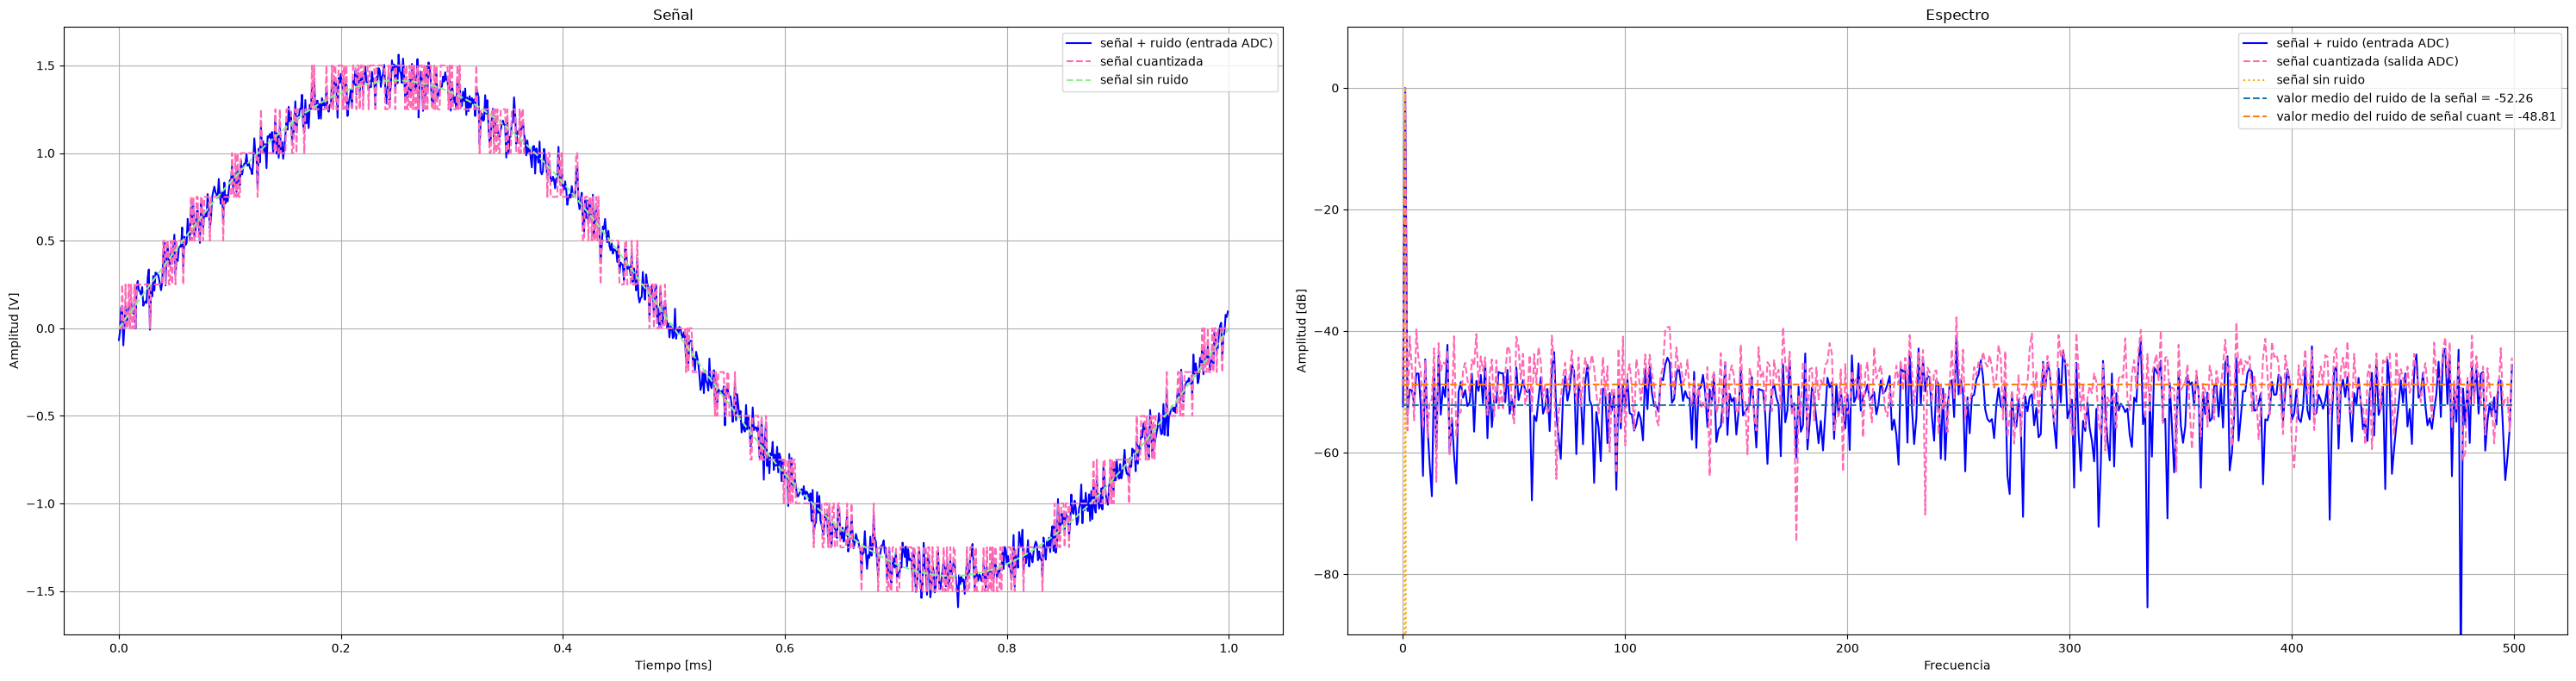

In [2]:
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(4, 1)
graficar_par(tt, xxr, xx, xxq, frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, 'red')

A continuacion, se observará lo mencionado anteriormente haciendo pruebas aumentando los bits de cuantizacion del ADC a 8 y 16 bits respectivamente pero manteniendo la constante de escala de potencias en 1.

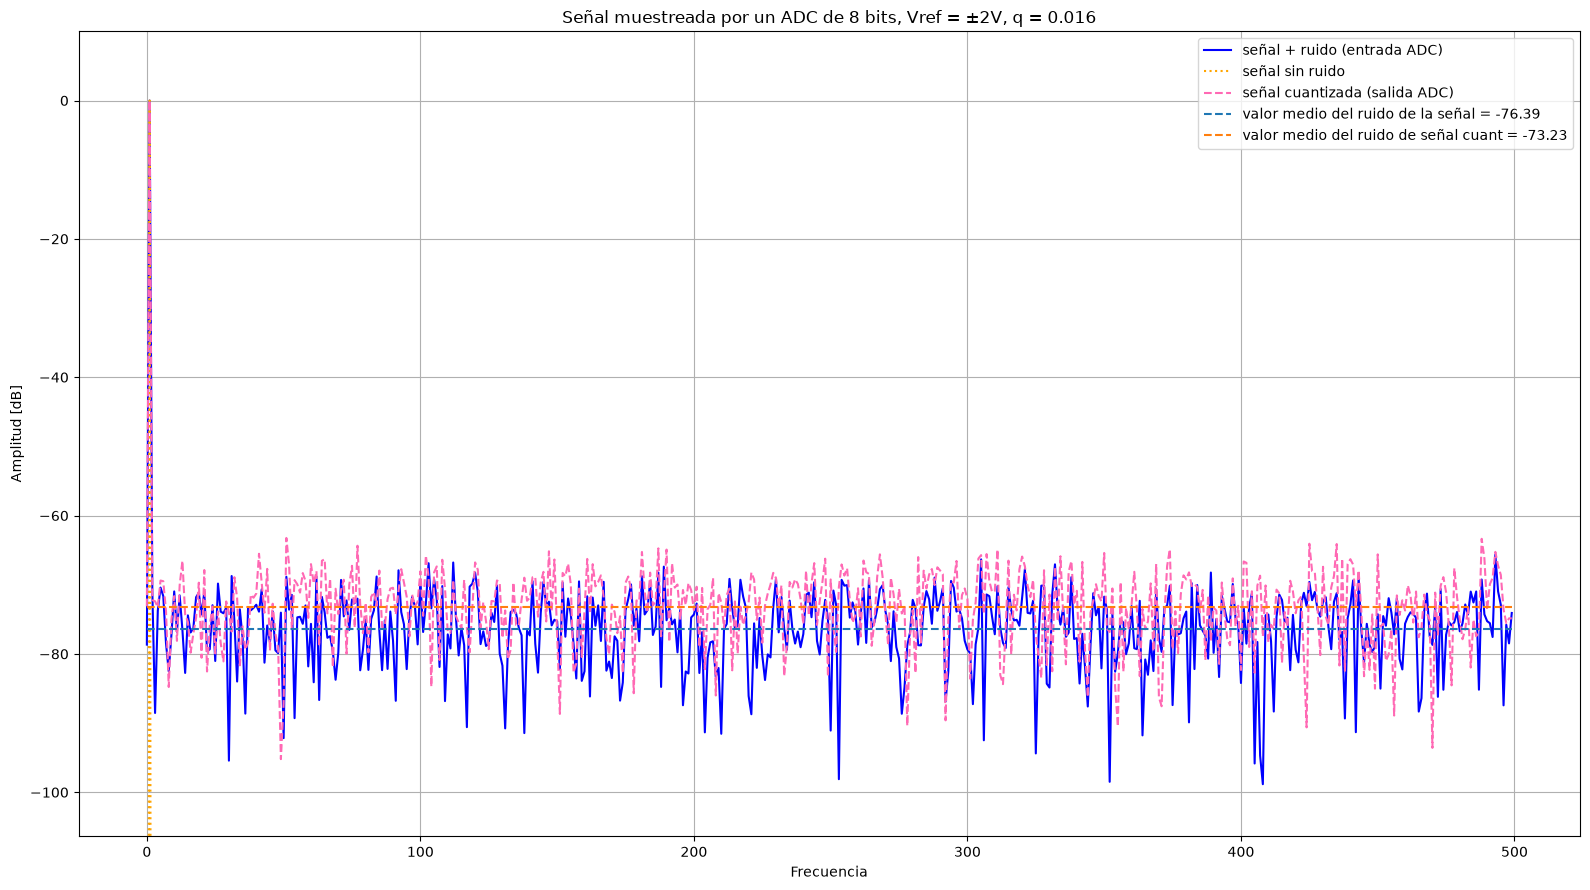

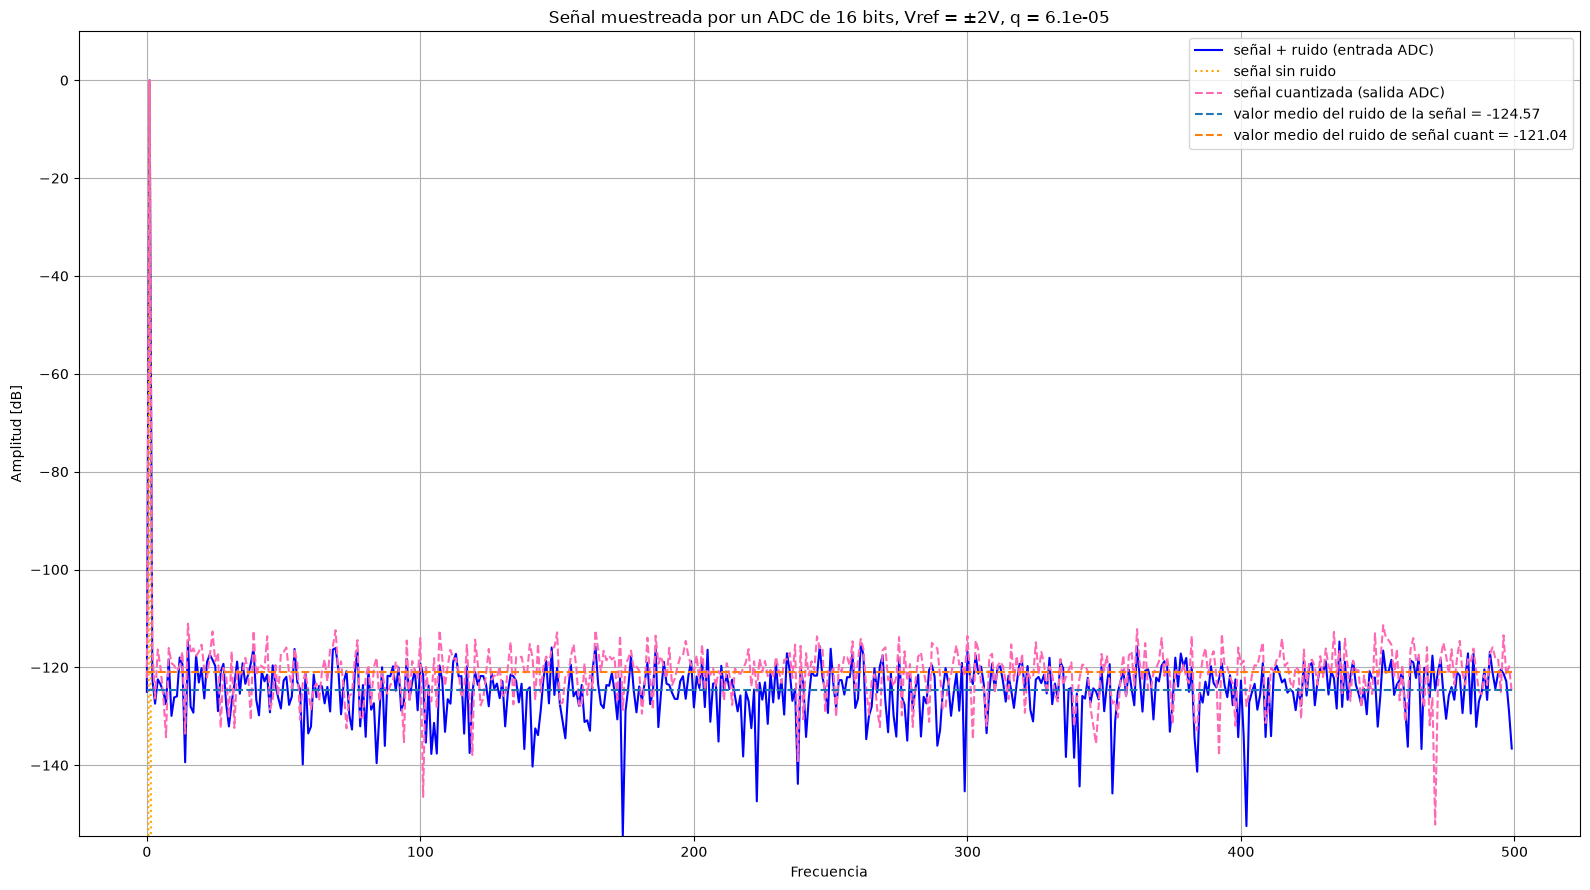

In [13]:
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(8, 1)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(16, 1)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)

Se observa que el piso de ruido por cuantizacion se mantiene siempre 4 dB por encima del analogico. Para ver esto con mas claridad de disminuirá el factor de escala de potencia a 1/10 y se haran pruebas con 4, 8 y 16 bits. Es decir se reducirá el ruido analogico a una decima parte del ruido por cuantizacion. 

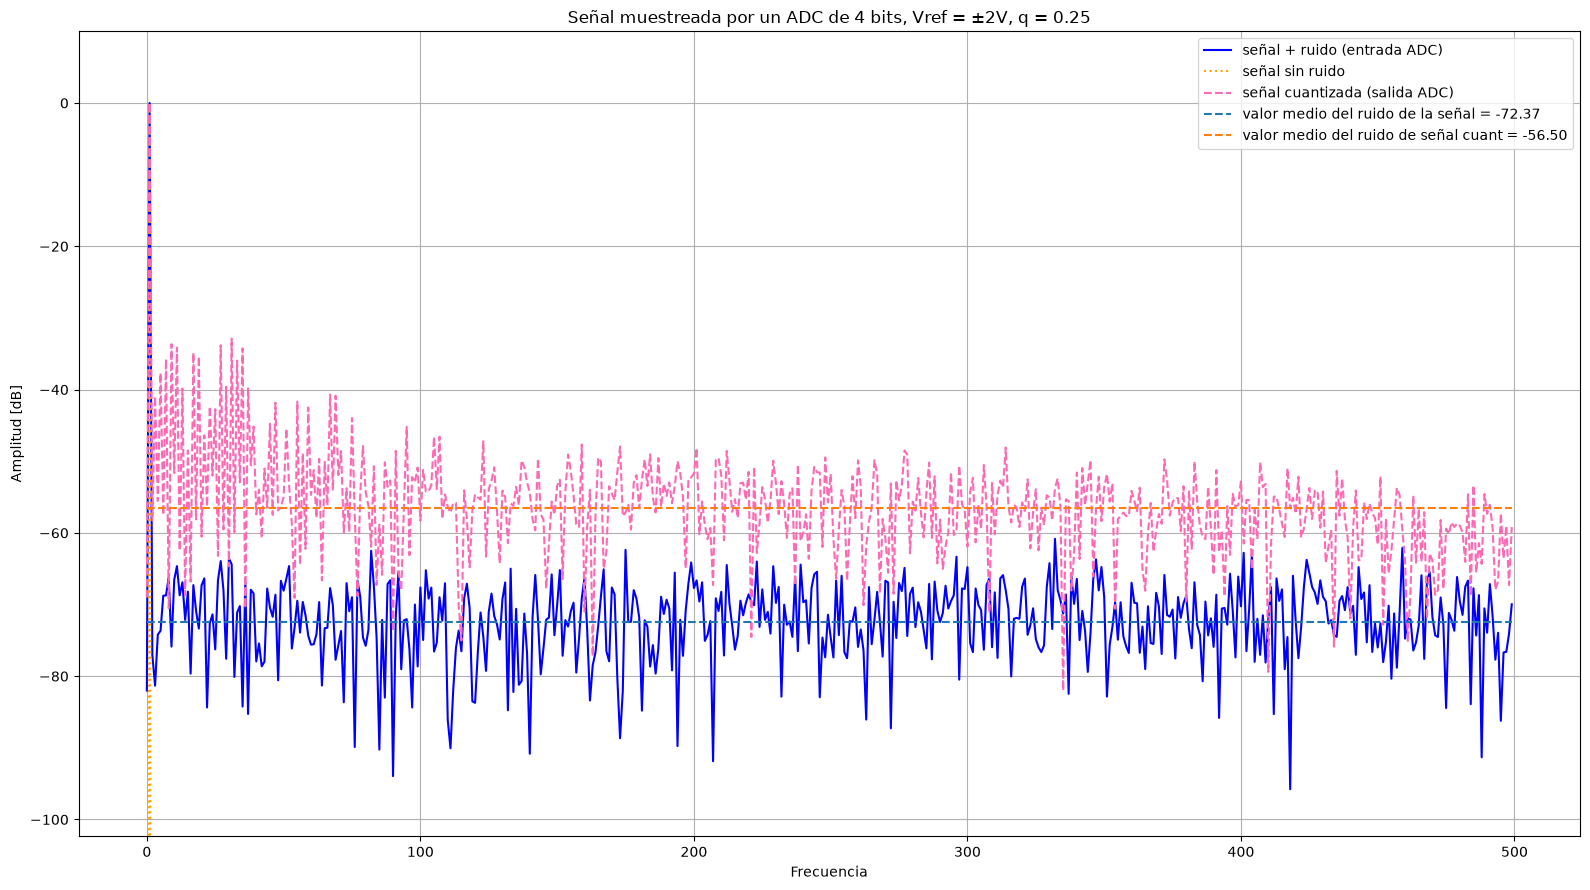

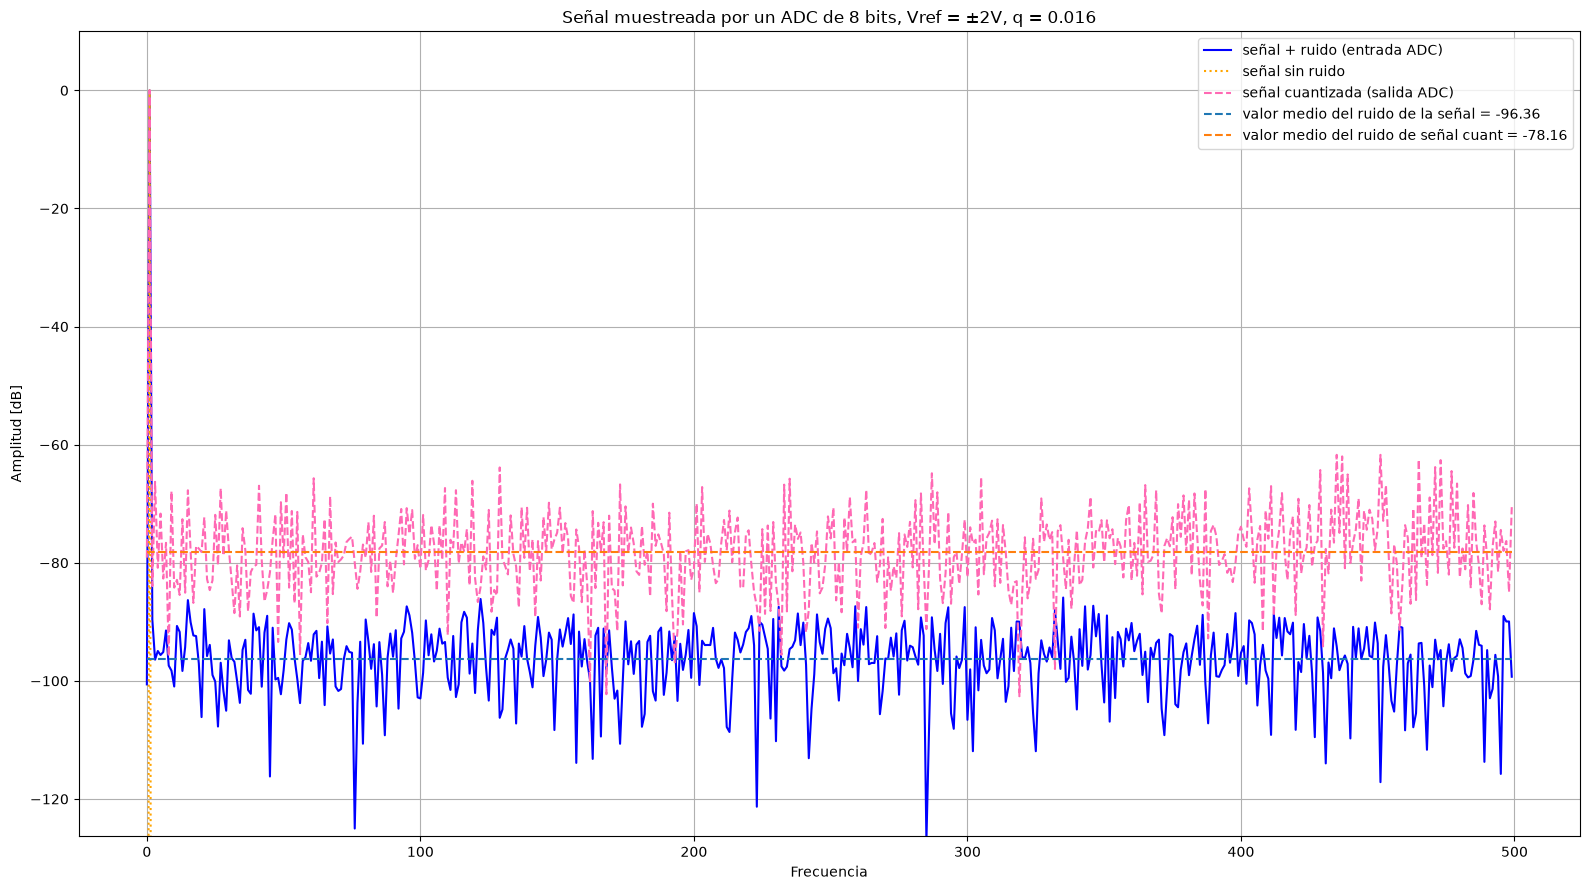

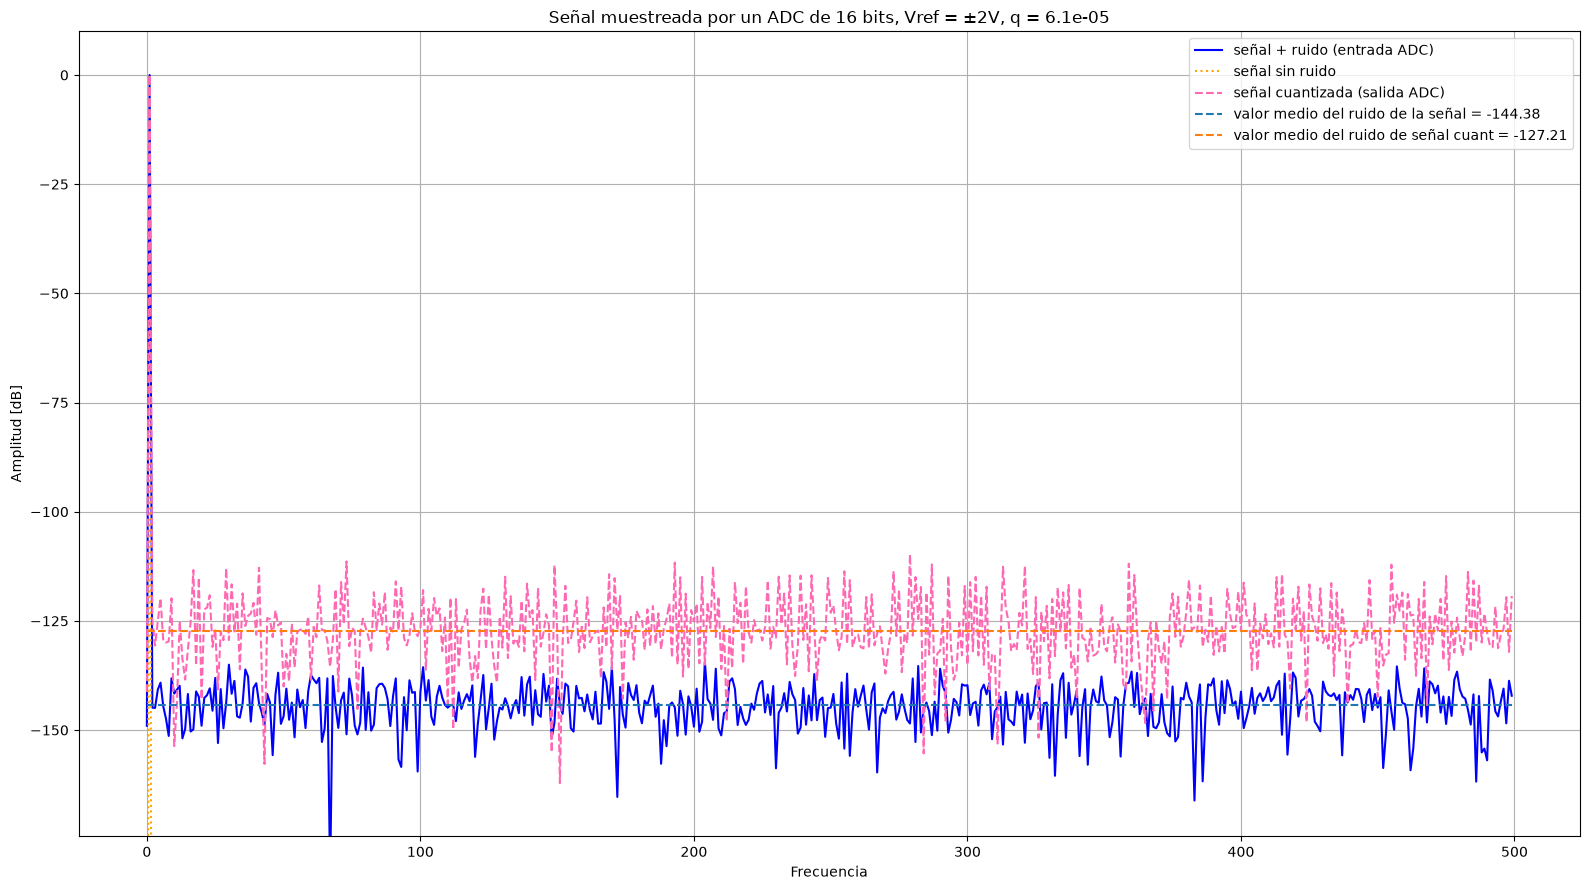

In [16]:
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(4, 1/10)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(8, 1/10)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(16, 1/10)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)

Se observa que bajando el piso de ruido analogico, sigue prevaleciendo el de cuantizaicon a la salida del ADC sin importar la cantidad de bits del paso de cuantizacion. Ahora, yendo al otro extremo, se aumentará el piso del ruido de la señal analogica aumentando el factor de escala kn a 10. 

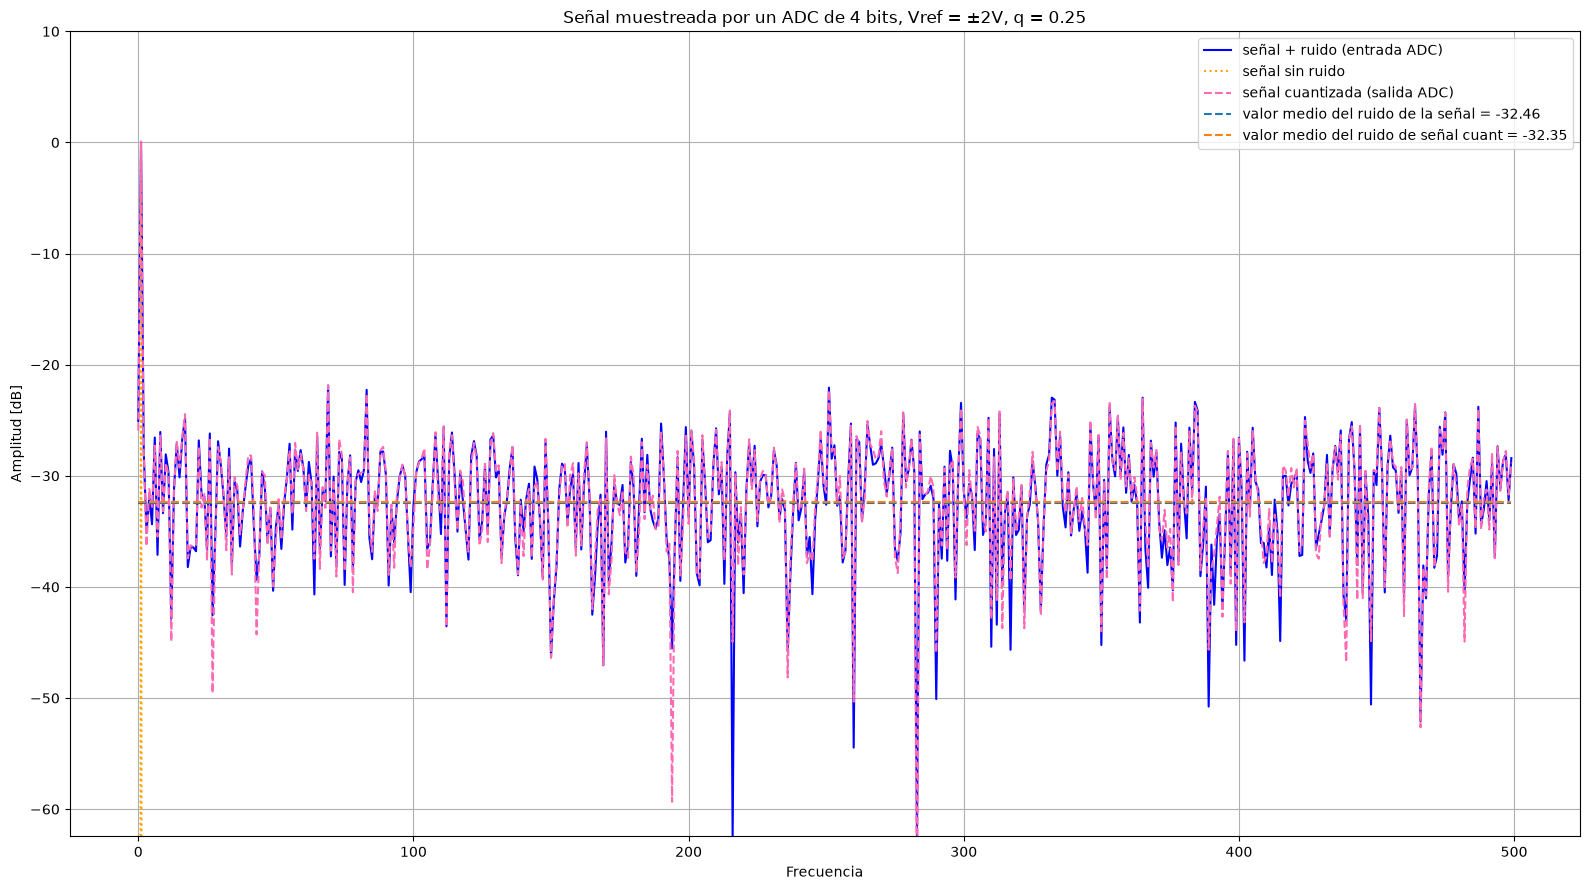

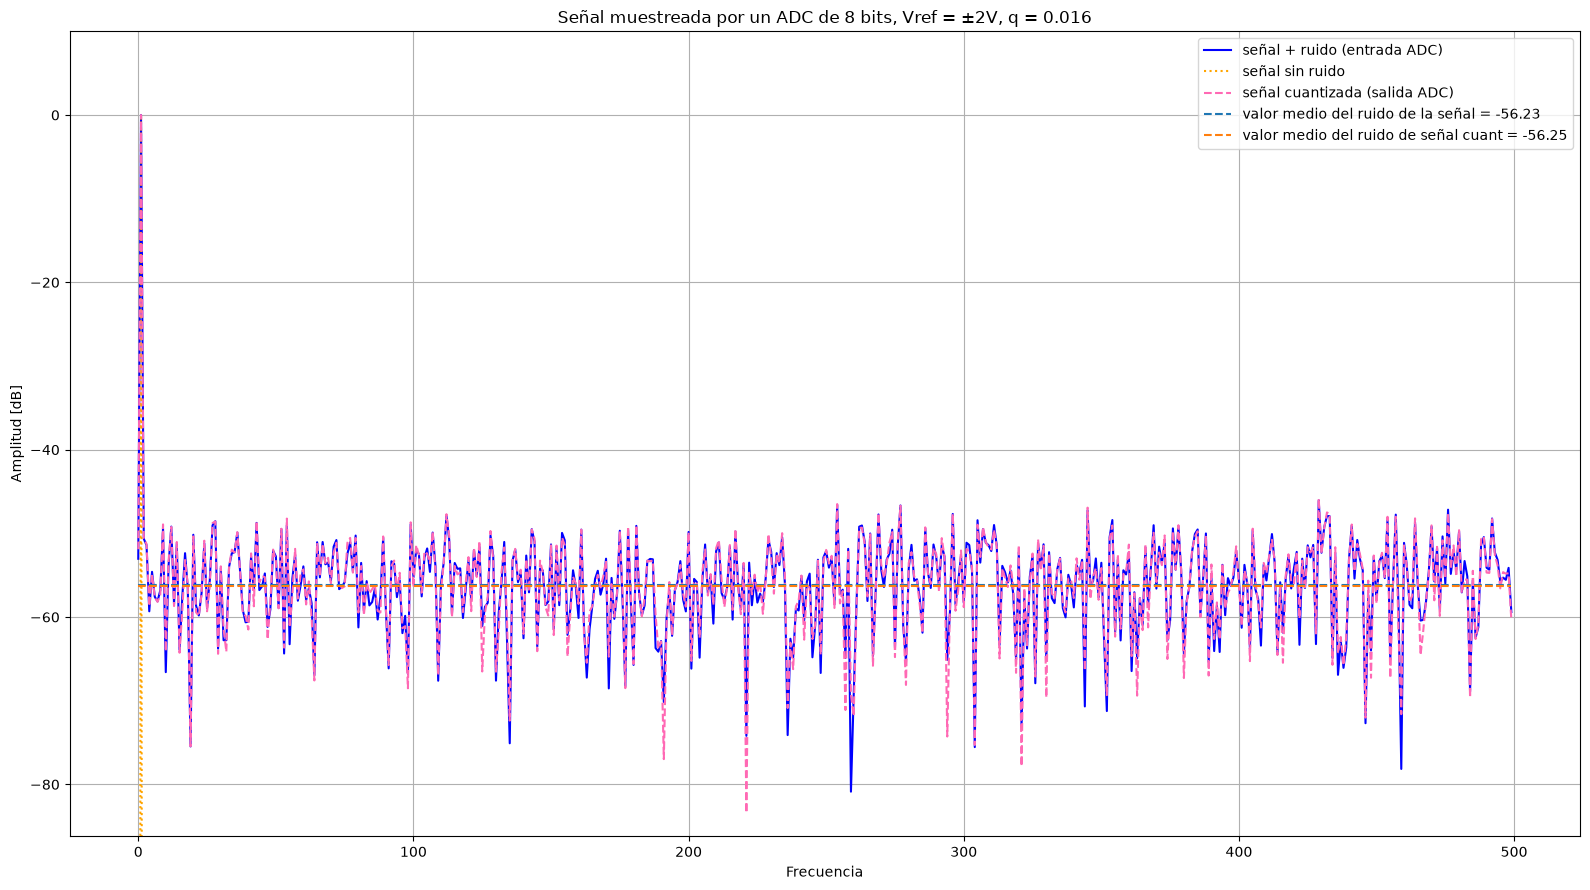

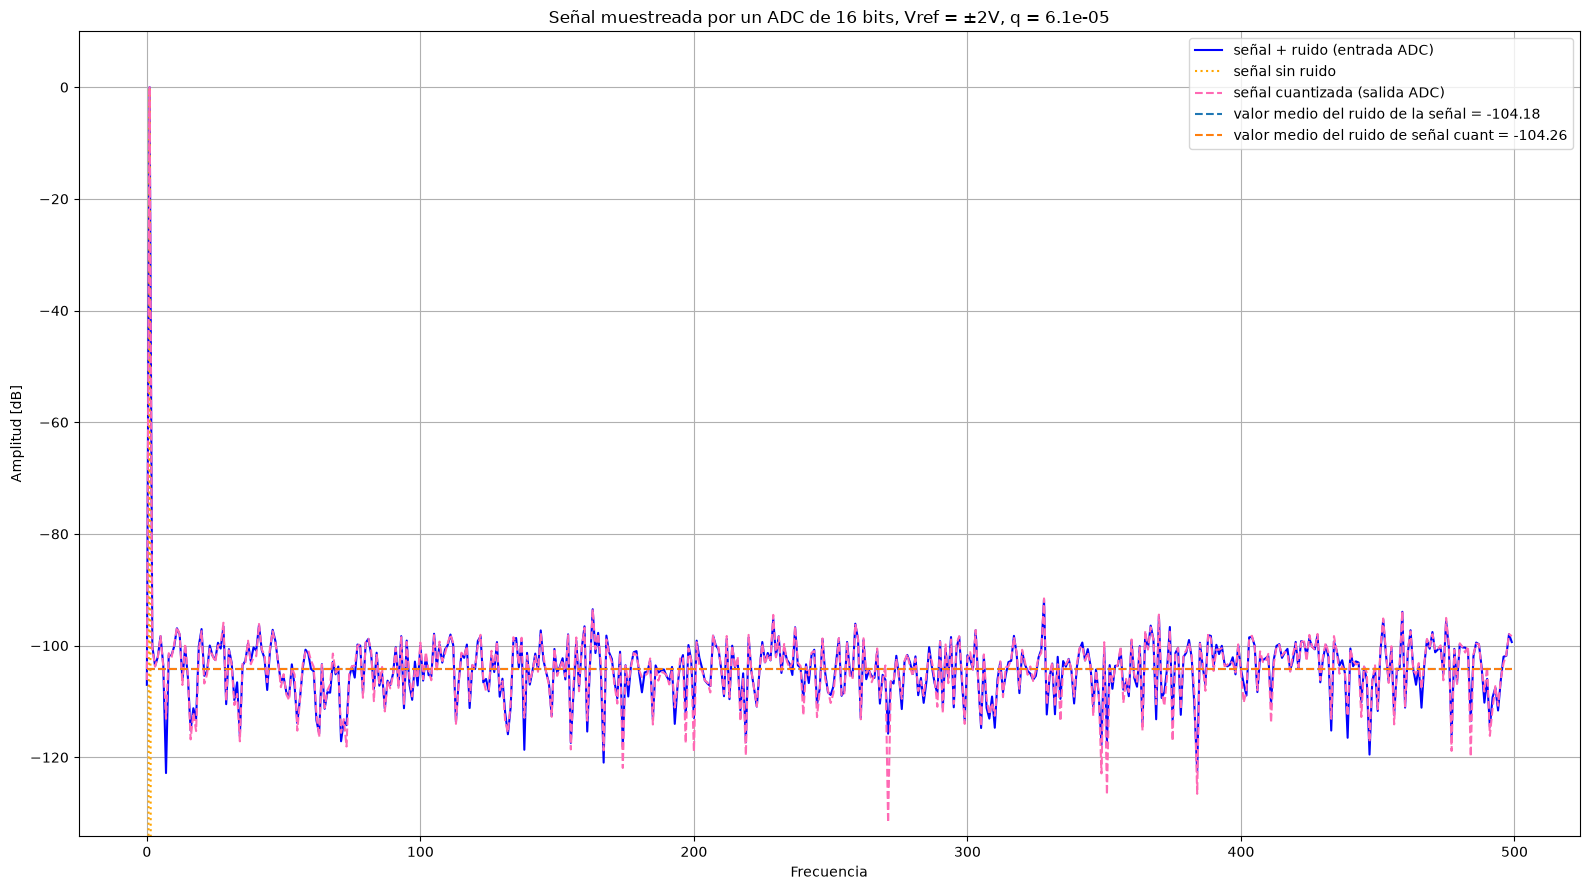

In [17]:
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(4, 10)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(8, 10)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)
xxr, xx, xxq, modulo_xxrtr_db, modulo_xxqtr_db, modulo_xxtr_db, B, Vfs, qq, nq = TS2(16, 10)
turbo_graficador(frec, modulo_xxrtr_db, modulo_xxtr_db, modulo_xxqtr_db, B, Vfs, qq)

La potencia de ruido analogico ahora es 10 veces mayor que la del ruido por cuantizacion pero se observa que el piso de ruido a la salida de ADC son practicamente iguales. Lo que sucede es el ADC esta muestreando con mucha precision mi señal analogica pero, de cierta manera, estaría gastando recursos de mi ADC en muestrear ruido. 
En conclusion, la cantidad de bits en el paso de cuantizacion de un ADC no mejorará la relacion señal-ruido de la señal original, a lo sumo es la misma. 


Por otra parte, mayor cantidad de bits de paso de cuantizacion tambien requieren mas recursos para la construccion del mismo. Es decir, si mi señal analogica tiene un snr muy bajo, es presindible aumentar la cantidad de bits del ADC ya que a la salida voy a tener 